# Model Inspection and Relevant Checkpoint Loading

This notebook inspects **only the relevant model checkpoint** for a selected dataset and safety area.

It supports:
- `AD_Cobots_Synthetic`
- `AD_Robotics_Hazards`
- `AD_MVTec`
- CPU / CUDA / Apple Silicon MPS
- automatic checkpoint discovery
- architecture inspection
- parameter counting
- forward-pass test
- input / reconstruction / difference-map visualization


## 1. Imports and Project Setup

In [2]:
import os
import sys
import time
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# ---------------------------------------------------------------------
# Project root
# ---------------------------------------------------------------------
# Option A: If notebook is inside AD_MultiPointThreshold/notebooks
# project_root = Path.cwd().parent

# Option B: Manually set your project root
project_root = Path(r"E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold")

scripts_dir = project_root / "scripts"
sys.path.insert(0, str(scripts_dir))

print(f"Project root: {project_root}")
print(f"Scripts dir:  {scripts_dir}")
print(f"Exists:       {project_root.exists()}")

# ---------------------------------------------------------------------
# Import project models
# ---------------------------------------------------------------------
try:
    import utils_model as utmc
    from utils_model import Encoder, Decoder, Discriminator
    print("✓ Imported Encoder, Decoder, Discriminator from utils_model.py")
except Exception as e:
    print("✗ Could not import project model classes.")
    print("  Check project_root and scripts_dir.")
    raise e

print(f"PyTorch version: {torch.__version__}")

Project root: E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold
Scripts dir:  E:/Cloud/RashidPHD/Codes/DistriMuSe/AD_MultiPointThreshold/scripts
Exists:       False
✗ Could not import project model classes.
  Check project_root and scripts_dir.


ModuleNotFoundError: No module named 'utils_model'

## 2. Select Dataset, Safety Area, and Checkpoint Location

In [2]:
# ---------------------------------------------------------------------
# Select what you want to inspect
# ---------------------------------------------------------------------
# DATASET_NAME = "AD_Cobots_Synthetic"   # Options: AD_Cobots_Synthetic, AD_Robotics_Hazards, AD_MVTec
# DATASET_NAME = "AD_Robotics_Hazards"   # Options: AD_Cobots_Synthetic, AD_Robotics_Hazards, AD_MVTec
DATASET_NAME = "AD_MVTec"   # Options: AD_Cobots_Synthetic, AD_Robotics_Hazards, AD_MVTec

if DATASET_NAME == "AD_Cobots_Synthetic":
    SAFETY_AREA = "RoboArm"            # Options: PLeft, PRight, RoboArm, ConvBelt
elif DATASET_NAME == "AD_Robotics_Hazards":
    SAFETY_AREA = "corridor"                # Options: PLeft, PRight, RoboArm, ConvBelt, or MVtec object name
elif DATASET_NAME == "AD_MVTec":
    SAFETY_AREA = "hazelnut"                 # Options: PLeft, PRight, RoboArm, ConvBelt, or MVtec object name
LATENT_DIMS = 64

# If you already know the exact checkpoint path, set it here.
# Otherwise keep None and the notebook will search automatically.
MODEL_PATH = None
# Example:
# MODEL_PATH = r"E:/PHD/repos/my_HF/AD_Cobots_Synthetic/model_RoboArm_64.pt"

# ---------------------------------------------------------------------
# Checkpoint root directories
# Edit these according to your PC.
# ---------------------------------------------------------------------
CHECKPOINT_ROOTS = {
    "AD_Cobots_Synthetic": project_root / "checkpoints" / "AD_Cobots_Synthetic",
    "AD_Robotics_Hazards": project_root / "checkpoints" / "AD_Robotics_Hazards",
    "AD_MVTec": project_root / "checkpoints" / "AD_MVTec",
}

# Optional: use environment variables if your checkpoints are outside repo
# Windows PowerShell example:
# $env:AD_COBOTS_CKPT="E:\PHD\repos\my_HF\AD_Cobots_Synthetic"
env_roots = {
    "AD_Cobots_Synthetic": os.environ.get("AD_COBOTS_CKPT"),
    "AD_Robotics_Hazards": os.environ.get("AD_ROBOTICS_HAZARDS_CKPT"),
    "AD_MVTec": os.environ.get("AD_MVTEC_CKPT"),
}

for key, value in env_roots.items():
    if value:
        CHECKPOINT_ROOTS[key] = Path(value)

print("Selection")
print("-" * 80)
print(f"Dataset:      {DATASET_NAME}")
print(f"Safety area:  {SAFETY_AREA}")
print(f"Latent dims:  {LATENT_DIMS}")
print("\nCheckpoint roots")
print("-" * 80)
for k, v in CHECKPOINT_ROOTS.items():
    print(f"{k:22s}: {v} | exists={Path(v).exists()}")

Selection
--------------------------------------------------------------------------------
Dataset:      AD_MVTec
Safety area:  hazelnut
Latent dims:  64

Checkpoint roots
--------------------------------------------------------------------------------
AD_Cobots_Synthetic   : E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_Cobots_Synthetic | exists=True
AD_Robotics_Hazards   : E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_Robotics_Hazards | exists=True
AD_MVTec              : E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_MVTec | exists=True


## 3. Device Selection

In [3]:
def resolve_device(prefer="auto"):
    """
    Resolve device for CPU, CUDA, or Apple Silicon MPS.
    """
    prefer = str(prefer).lower()

    if prefer == "cpu":
        return torch.device("cpu")

    if prefer == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        print("CUDA requested but unavailable. Falling back to CPU.")
        return torch.device("cpu")

    if prefer == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        print("MPS requested but unavailable. Falling back to CPU.")
        return torch.device("cpu")

    # auto
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = resolve_device("auto")

print("=" * 80)
print("DEVICE INFORMATION")
print("=" * 80)
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU name:      {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:  {torch.version.cuda}")
    print(f"GPU memory:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
elif device.type == "mps":
    print("Apple Silicon MPS is available.")
else:
    print("Using CPU.")

DEVICE INFORMATION
Using device: cuda
GPU name:      NVIDIA GeForce RTX 4070 Laptop GPU
CUDA version:  11.8
GPU memory:    8.59 GB


## 4. Find the Relevant Checkpoint

In [4]:
def list_checkpoints(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(root.rglob("*.pt"))


def find_relevant_checkpoint(dataset_name, safety_area, latent_dims=64, model_path=None):
    if model_path is not None and str(model_path).strip() != "":
        model_path = Path(model_path)
        if model_path.exists():
            return model_path
        raise FileNotFoundError(f"MODEL_PATH does not exist: {model_path}")

    root = CHECKPOINT_ROOT / dataset_name

    if not root.exists():
        raise FileNotFoundError(f"Checkpoint root does not exist: {root}")

    all_ckpts = sorted(root.rglob("*.pt"))

    if len(all_ckpts) == 0:
        raise FileNotFoundError(f"No .pt checkpoints found under: {root}")

    safety_area_lower = safety_area.lower()

    candidate_patterns = [
        f"model_{safety_area}_{latent_dims}.pt",
        f"model_{safety_area_lower}_{latent_dims}.pt",
        f"*{safety_area}*{latent_dims}*.pt",
        f"*{safety_area_lower}*{latent_dims}*.pt",
    ]

    # Special case: Robotics Hazards corridor checkpoint
    if dataset_name.lower() in ["ad_robotics_hazards", "robotics_hazards"]:
        candidate_patterns.extend([
            f"model_corridor_{latent_dims}.pt",
            f"*corridor*{latent_dims}*.pt",
        ])

    matches = []

    for pattern in candidate_patterns:
        matches.extend(list(root.rglob(pattern)))

    matches = sorted(set(matches))

    if len(matches) > 0:
        return matches[0]

    available = "\n".join([f"- {p.relative_to(root)}" for p in all_ckpts[:50]])

    raise FileNotFoundError(
        f"No relevant checkpoint found for dataset={dataset_name}, "
        f"safety_area={safety_area}, latent_dims={latent_dims}\n\n"
        f"Available checkpoints under {root}:\n{available}"
    )


from pathlib import Path

# Root folder containing all downloaded checkpoint repositories
CHECKPOINT_ROOT = Path(
    r"E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints"
)

print("Checkpoint root:", CHECKPOINT_ROOT)
print("Exists:", CHECKPOINT_ROOT.exists())

model_path = find_relevant_checkpoint(
    dataset_name=DATASET_NAME,
    safety_area=SAFETY_AREA,
    latent_dims=LATENT_DIMS,
    model_path=MODEL_PATH
)

print("=" * 80)
print("SELECTED CHECKPOINT")
print("=" * 80)
print(model_path)
print(f"Size: {model_path.stat().st_size / (1024 ** 2):.2f} MB")

Checkpoint root: E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints
Exists: True
SELECTED CHECKPOINT
E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_MVTec\model_hazelnut_64.pt
Size: 232.68 MB


## 5. Safe Checkpoint Loading

In [5]:
def count_parameters(model):
    """Count total and trainable parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def load_torch_checkpoint(path):
    """
    Load checkpoint safely for local trusted checkpoints.

    PyTorch 2.6+ may default to weights_only=True in some contexts.
    Your checkpoints contain dictionaries and may require weights_only=False.
    Only use weights_only=False for checkpoints you trust.
    """
    path = Path(path)

    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except Exception as safe_error:
        print("Safe weights_only=True loading failed.")
        print("Falling back to weights_only=False for trusted local checkpoint.")
        print(f"Reason: {str(safe_error)[:200]}...")
        return torch.load(path, map_location="cpu", weights_only=False)


def get_state_dict_from_checkpoint(checkpoint, possible_keys):
    """
    Extract a state_dict from possible checkpoint key names.
    """
    for key in possible_keys:
        if isinstance(checkpoint, dict) and key in checkpoint:
            return checkpoint[key], key
    return None, None


def load_model_checkpoint(model_path, latent_dims=64, device="cpu"):
    """
    Load Encoder, Decoder, and Discriminator from a VAE-GAN checkpoint.
    Supports multiple checkpoint key conventions.
    """
    start_time = time.time()
    checkpoint = load_torch_checkpoint(model_path)
    load_time = time.time() - start_time

    print("=" * 80)
    print("CHECKPOINT KEYS")
    print("=" * 80)

    if isinstance(checkpoint, dict):
        for k in checkpoint.keys():
            print(f"- {k}")
    else:
        raise TypeError(f"Unsupported checkpoint type: {type(checkpoint)}")

    models = {}

    encoder_sd, encoder_key = get_state_dict_from_checkpoint(
        checkpoint,
        ["encoder_state_dict", "encoder", "encoder_sd", "netE", "E"]
    )

    decoder_sd, decoder_key = get_state_dict_from_checkpoint(
        checkpoint,
        ["decoder_state_dict", "decoder", "decoder_sd", "generator_state_dict", "generator", "netG", "G"]
    )

    discriminator_sd, discriminator_key = get_state_dict_from_checkpoint(
        checkpoint,
        ["discriminator_state_dict", "discriminator", "discriminator_sd", "netD", "D"]
    )

    if encoder_sd is not None:
        encoder = Encoder(z_size=latent_dims)
        encoder.load_state_dict(encoder_sd)
        encoder.to(device)
        encoder.eval()
        models["encoder"] = encoder
        print(f"✓ Loaded encoder from key: {encoder_key}")
    else:
        print("⚠ Encoder weights not found.")

    if decoder_sd is not None:
        decoder = Decoder(z_size=latent_dims)
        decoder.load_state_dict(decoder_sd)
        decoder.to(device)
        decoder.eval()
        models["decoder"] = decoder
        print(f"✓ Loaded decoder from key: {decoder_key}")
    else:
        print("⚠ Decoder weights not found.")

    if discriminator_sd is not None:
        discriminator = Discriminator()
        discriminator.load_state_dict(discriminator_sd)
        discriminator.to(device)
        discriminator.eval()
        models["discriminator"] = discriminator
        print(f"✓ Loaded discriminator from key: {discriminator_key}")
    else:
        print("⚠ Discriminator weights not found.")

    if len(models) == 0:
        raise ValueError("No valid model components were loaded from this checkpoint.")

    return {
        "success": True,
        "models": models,
        "checkpoint": checkpoint,
        "load_time": load_time,
        "model_path": Path(model_path),
    }


loaded = load_model_checkpoint(model_path, latent_dims=LATENT_DIMS, device=device)
models_dict = loaded["models"]

print("\nLoad summary")
print("-" * 80)
print(f"Loaded components: {list(models_dict.keys())}")
print(f"Load time: {loaded['load_time']:.3f}s")

Safe weights_only=True loading failed.
Falling back to weights_only=False for trusted local checkpoint.
Reason: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) Re-running `torch.load` with `weigh...
CHECKPOINT KEYS
- encoder_state_dict
- decoder_state_dict
- discriminator_state_dict
- optimizer_enc_state_dict
- optimizer_dec_state_dict
- loss_history
✓ Loaded encoder from key: encoder_state_dict
✓ Loaded decoder from key: decoder_state_dict
✓ Loaded discriminator from key: discriminator_state_dict

Load summary
--------------------------------------------------------------------------------
Loaded components: ['encoder', 'decoder', 'discriminator']
Load time: 0.465s


## 6. Inspect Architecture and Parameters

In [6]:
print("=" * 80)
print("MODEL ARCHITECTURE DETAILS")
print("=" * 80)

summary_rows = []

for component_name, model in models_dict.items():
    total_params, trainable_params = count_parameters(model)

    print(f"\n{component_name.upper()}")
    print("-" * 80)
    print(f"Total parameters:     {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Device:               {next(model.parameters()).device}")
    print("\nArchitecture:")
    print(model)

    summary_rows.append({
        "dataset": DATASET_NAME,
        "safety_area": SAFETY_AREA,
        "checkpoint": model_path.name,
        "component": component_name,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "device": str(next(model.parameters()).device),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

MODEL ARCHITECTURE DETAILS

ENCODER
--------------------------------------------------------------------------------
Total parameters:     6,950,976
Trainable parameters: 6,950,976
Device:               cuda:0

Architecture:
Encoder(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=32768, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=32768, out_features=64, bias=True)
)

DECODER
--------------------------------------------------------------------------------
Total parameters:     4,885,955
Trainable parameters: 4,885,955
Device:               cuda:0

Arc

,dataset,safety_area,checkpoint,component,total_params,trainable_params,device
0,AD_MVTec,hazelnut,model_hazelnut_64.pt,encoder,6950976,6950976,cuda:0
1,AD_MVTec,hazelnut,model_hazelnut_64.pt,decoder,4885955,4885955,cuda:0
2,AD_MVTec,hazelnut,model_hazelnut_64.pt,discriminator,8482369,8482369,cuda:0


## 7. Forward-Pass Test

In [7]:
print("=" * 80)
print("FORWARD PASS TEST")
print("=" * 80)

test_batch_size = 2
x = torch.randn(test_batch_size, 3, 128, 128, device=device)

print(f"Input shape: {tuple(x.shape)}")

with torch.no_grad():
    if "encoder" in models_dict:
        mu, logvar = models_dict["encoder"](x)
        print(f"Encoder output:")
        print(f"  mu:     {tuple(mu.shape)}")
        print(f"  logvar: {tuple(logvar.shape)}")
    else:
        mu, logvar = None, None
        print("Encoder not available.")

    if "encoder" in models_dict and "decoder" in models_dict:
        z = utmc.reparameterize(mu, logvar)
        x_recon = models_dict["decoder"](z)

        print(f"Latent z:       {tuple(z.shape)}")
        print(f"Reconstruction: {tuple(x_recon.shape)}")

        mae = torch.mean(torch.abs(x - x_recon)).item()
        mse = torch.mean((x - x_recon) ** 2).item()

        print(f"Reconstruction MAE: {mae:.6f}")
        print(f"Reconstruction MSE: {mse:.6f}")

    if "discriminator" in models_dict:
        try:
            d_out = models_dict["discriminator"](x)
            if isinstance(d_out, tuple):
                print("Discriminator output:")
                for idx, item in enumerate(d_out):
                    if torch.is_tensor(item):
                        print(f"  output[{idx}]: {tuple(item.shape)}")
                    else:
                        print(f"  output[{idx}]: {type(item)}")
            else:
                print(f"Discriminator output: {tuple(d_out.shape)}")
        except Exception as e:
            print(f"Discriminator forward pass failed: {e}")

FORWARD PASS TEST
Input shape: (2, 3, 128, 128)
Encoder output:
  mu:     (2, 64)
  logvar: (2, 64)
Latent z:       (2, 64)
Reconstruction: (2, 3, 128, 128)
Reconstruction MAE: 1.027646
Reconstruction MSE: 1.613219
Discriminator output: (2, 1)


## 8. Plot Input, Reconstruction, and Difference Map

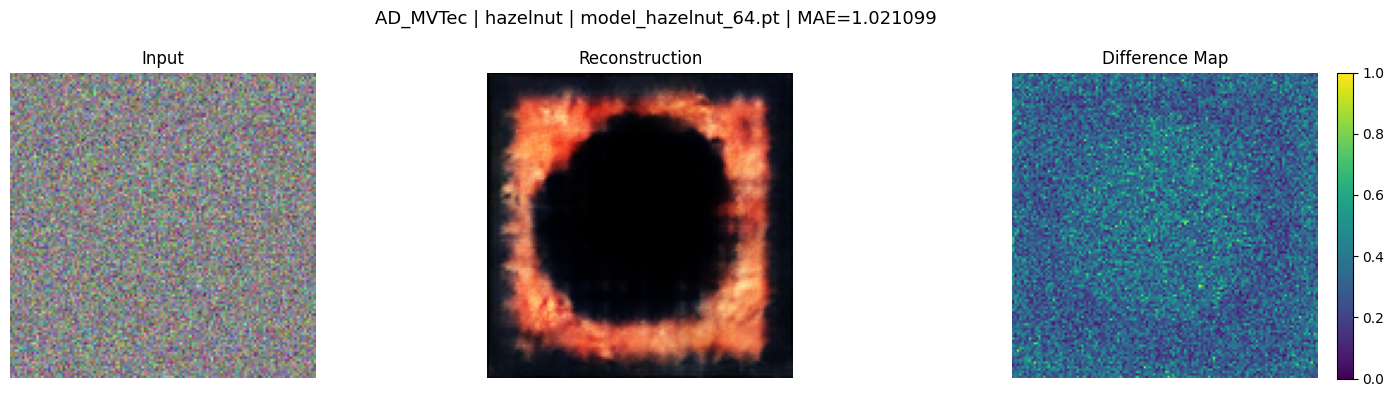

In [8]:
def normalize_for_plot(x):
    x = np.asarray(x)
    x_min, x_max = x.min(), x.max()
    return (x - x_min) / (x_max - x_min + 1e-8)


def tensor_to_hwc_image(t):
    """
    Convert CHW torch tensor to HWC numpy image for plotting.
    """
    t = t.detach().cpu()
    if t.ndim == 4:
        t = t[0]
    return t.permute(1, 2, 0).numpy()


if "encoder" not in models_dict or "decoder" not in models_dict:
    print("Encoder/Decoder not available. Cannot plot reconstruction.")
else:
    torch.manual_seed(42)
    test_input = torch.randn(1, 3, 128, 128, device=device)

    encoder = models_dict["encoder"]
    decoder = models_dict["decoder"]

    with torch.no_grad():
        mu, logvar = encoder(test_input)
        z = utmc.reparameterize(mu, logvar)
        x_recon = decoder(z)

    input_img = test_input.detach().cpu()[0]
    recon_img = x_recon.detach().cpu()[0]

    input_np = tensor_to_hwc_image(input_img)
    recon_np = tensor_to_hwc_image(recon_img)

    diff_map = torch.abs(input_img - recon_img).mean(dim=0).numpy()

    input_vis = normalize_for_plot(input_np)
    recon_vis = normalize_for_plot(recon_np)
    diff_vis = normalize_for_plot(diff_map)

    recon_error = torch.abs(test_input - x_recon).mean().item()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(input_vis)
    axes[0].set_title("Input")

    axes[1].imshow(recon_vis)
    axes[1].set_title("Reconstruction")

    im = axes[2].imshow(diff_vis)
    axes[2].set_title("Difference Map")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"{DATASET_NAME} | {SAFETY_AREA} | {model_path.name} | MAE={recon_error:.6f}",
        fontsize=13
    )
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 9. Optional: Inspect All Checkpoints in Selected Dataset

In [9]:
root = CHECKPOINT_ROOTS[DATASET_NAME]
all_ckpts = list_checkpoints(root)

rows = []
for p in all_ckpts:
    rows.append({
        "checkpoint": p.name,
        "relative_path": str(p.relative_to(root)),
        "size_mb": round(p.stat().st_size / (1024 ** 2), 2),
        "selected": p.resolve() == model_path.resolve(),
    })

ckpt_df = pd.DataFrame(rows)
ckpt_df

,checkpoint,relative_path,size_mb,selected
0,model_bottle_64.pt,model_bottle_64.pt,232.68,False
1,model_cable_64.pt,model_cable_64.pt,232.68,False
2,model_capsule_64.pt,model_capsule_64.pt,232.68,False
3,model_carpet_64.pt,model_carpet_64.pt,232.67,False
4,model_grid_64.pt,model_grid_64.pt,232.67,False
5,model_hazelnut_64.pt,model_hazelnut_64.pt,232.68,True
6,model_leather_64.pt,model_leather_64.pt,232.68,False
7,model_metal_nut_64.pt,model_metal_nut_64.pt,232.68,False
8,model_pill_64.pt,model_pill_64.pt,232.67,False
9,model_screw_64.pt,model_screw_64.pt,232.68,False


## 10. Final Summary

In [10]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Dataset:      {DATASET_NAME}")
print(f"Safety area:  {SAFETY_AREA}")
print(f"Checkpoint:   {model_path}")
print(f"Device:       {device}")
print(f"Components:   {list(models_dict.keys())}")

if "encoder" in models_dict and "decoder" in models_dict:
    print("Status:       ✓ Relevant model loaded and reconstruction test completed.")
else:
    print("Status:       ⚠ Model loaded, but encoder/decoder pair is incomplete.")

FINAL SUMMARY
Dataset:      AD_MVTec
Safety area:  hazelnut
Checkpoint:   E:\Cloud\RashidPHD\Codes\DistriMuSe\AD_MultiPointThreshold\checkpoints\AD_MVTec\model_hazelnut_64.pt
Device:       cuda
Components:   ['encoder', 'decoder', 'discriminator']
Status:       ✓ Relevant model loaded and reconstruction test completed.
